# Red Neuronal Lagrangiana para resolver la dinámica de una partícula cargada bajo un potencial eléctrico y magnético simétrico
# Autores: Juan Manuel Bonilla Arce* & Sebastián Alí Sacasa Céspedes*
## *Escuela de Física, Universidad de Costa Rica (UCR), San Pedro de Montes de Oca, San José, 11501-2060, Costa Rica
## Correos correspondientes: juan.bonillaarce@ucr.ac.cr & sebastian.sacasa@ucr.ac.cr
### 21 de julio, 2026


In [1]:
#Aquí se añade todo lo que se vaya a importar para el proyecto

import jax
import jax.numpy as jnp
from jax import grad, jit, hessian, jacobian
from functools import partial
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Lagrangiano

def lagrangiano(r, rPunto, m, q, Ex, Ey, B):
    """
    Calcula el lagrangiano de una partícula cargada bajo el potencial generado por la fuerza de Lorentz en 2D

    Args:

        r : jnp.array([x, y]), posiciones
        rPunto : jnp.array([vx, vy]), velocidades
        m : float, masa
        q : float, carga eléctrica
        Ex : float, campo eléctrico en x
        Ey : float, campo eléctrico en y
        B : float, campo magnético en z

    Returns:
        L : escalar, valor del Lagrangiano
    """
    x,  y  = r
    vx, vy = rPunto

    # energía cinética
    T = 0.5 * m * (vx**2 + vy**2)

    # potencial eléctrico
    uElec = -q * (Ex * x + Ey * y)

    # potencial magnético (simétrico)
    uMag = (q * B / 2.0) * (x * vy - y * vx)

    # Lagrangiano
    return T - uElec - uMag

In [3]:
#Euler-Lagrange

@partial(jit, static_argnums=(0,))  # Aquí partial permite pasarle opciones a jit como si fueran argumentos, luego
                                    # jit compila la función para que corra más rápido y, finalmente, static_argnums=(0,)
                                    # tiene argumento 0 porque fnLagrangiano es una función, no un array, JAX no lo compila
def eulerLagrange(funcLagrangiano, r, rPunto, m, q, Ex, Ey, B):
    """
    Resuelve la ecuación de Euler Lagrange

    Args:

        funcLagrangiano: función del lagrangaino con argumentos (r, rPunto, m, q, Ex, Ey, B)
        r : jnp.array([x, y]), posiciones
        rPunto : jnp.array([vx, vy]), velocidades
        m : float, masa
        q : float, carga eléctrica
        Ex : float, campo eléctrico en x
        Ey : float, campo eléctrico en y
        B : float, campo magnético en z

    Returns:
        rPuntoPunto :  jnp.array([ax, ay], aceleraciones
    """
    rPuntoPunto =(

    jnp.linalg.pinv(hessian(funcLagrangiano,1)(r, rPunto, m, q, Ex, Ey, B)) @ ( #inv del Hesiano de L respecto a rPunto
    grad(funcLagrangiano, 0)(r, rPunto, m, q, Ex, Ey, B)                        #gradiente de L respecto a r
    - jacobian(jacobian(funcLagrangiano,1), 0)(r, rPunto, m, q, Ex, Ey, B) @ rPunto )   #término mixto

    )

    return rPuntoPunto


In [4]:
#Corremos esta parte analítica

def integrador(funcLagrangiano, funcEulerLagrange, r0, rPunto0, m, q, Ex, Ey, B, dt=0.01, pasos=1000):
    """
    Integra la trayectoria de la partícula usando el método de Euler

    Args:

        funcLagrangiano: función del lagrangaino con argumentos (r, rPunto, m, q, Ex, Ey, B)
        funcEulerLagrange: función de la ecuación de Euler Lagrange con argumentos (funcLagrangiano, r, rPunto, m, q, Ex, Ey, B)
        r : jnp.array([x, y]), posiciones
        rPunto : jnp.array([vx, vy]), velocidades
        m : float, masa
        q : float, carga eléctrica
        Ex : float, campo eléctrico en x
        Ey : float, campo eléctrico en y
        B : float, campo magnético en z
        dt: float, paso temporal
        pasos: int, número de pasos

    Returns:
        rs: jnp.array de posiciones en cada paso
        rPuntos: jnp.array de velocidades en cada paso

    """

    r = r0 #variables que sirven para ir actualizando en cada paso
    rPunto = rPunto0

    rs = [r0] #para ir guardando los pasos
    rPuntos =[rPunto0]

    for i in range(pasos):

        #aceleración con la función que se definió anteriormente de Euler Lagrange
        rPuntoPunto = funcEulerLagrange(funcLagrangiano, r, rPunto, m, q, Ex, Ey, B)

        #actualización de posición y velocidad

        rPunto = rPunto + dt*rPuntoPunto
        r = r + dt*rPunto

        rs.append(r)
        rPuntos.append(rPunto)

    return jnp.array(rs), jnp.array(rPuntos)








    return


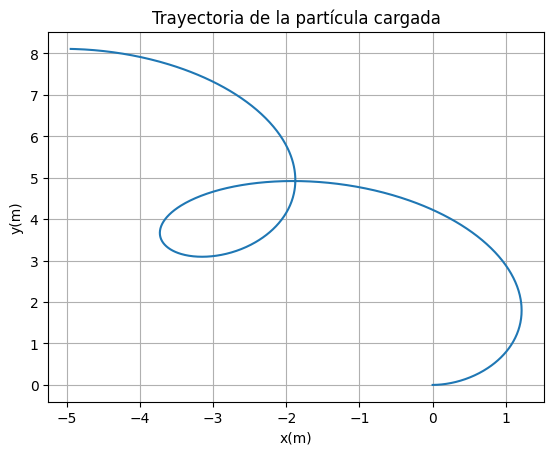

In [5]:
#Se definen los parámetros y se hace una gráfica de prueba

#Parámetros

m = 1.0 #kg
q = 1.0 #C
Ex = 0.5 #N/C
Ey = 0.5 #N/C
B = 1.0 #T

#Condiciones iniciales (caso para v0y = 0)

r0 = jnp.array([0.0,0.0]) #inicia en el origen con entradas en m
rPunto0 = jnp.array([1.0,0.0]) #m/s

#Simulación

rs, rPuntos = integrador(lagrangiano, eulerLagrange, r0, rPunto0, m, q, Ex, Ey, B) #no le cambié dt y pasos default

#Gráfica

fig = plt.figure()
plt.plot(rs[:, 0], rs[:, 1])
plt.xlabel("x(m)")
plt.ylabel("y(m)")
plt.title("Trayectoria de la partícula cargada")
plt.grid(True)
plt.show()

Dado que el lagrangiano mapea como $$\mathcal{L}_{\theta}: {D}  \subseteq \mathbb{R}^n\times \mathbb{R}^n \mapsto \mathbb{R}$$ con $$(q, \dot{q}) \mapsto \mathcal{L}_{\theta}(q, \dot{q})$$

In [6]:
# En esta sección de implementa el algoritmo de la red neuronal para aproximar la solución de la ecuación de Euler Lagrange.

import jax
import jax.numpy as jnp
import numpy as np
import optax
from functools import partial
jax.config.update("jax_enable_x64", True) # Esto es para que JAX use precisión de 64 bits, lo cual es importante para cálculos numéricos más precisos.
# En este caso para la matriz hessiana, que es la inversa de la matriz de masa efectiva, y para evitar problemas de precisión en la optimización.

DIM =2 #dimensión del espacio

def L_true(r, dr):

    return lagrangiano(r, dr, m, q, Ex, Ey, B)


M1, M2, L1, L2, GG= 1.0, 1.232, 1.1, 1.2, 9.8 #número de capas y neuronas por capa para las redes de masa efectiva y Lagrangiano

def L_pendulo_doble(r,rd):

    t1, t2 = r[0], r[1]
    w1, w2 = rd[0], rd[1]
    T1=0.5*M1*(L1*w1)**2
    T2=0.5*M2*((L1*w1)**2+(L2*w2)**2+2*L1*L2*w1*w2*jnp.cos(t1-t2))

    y1=-L1*jnp.cos(t1)
    y2=y1-L2*jnp.cos(t2)
    V1=M1*GG*y1+M2*GG*y2
    return T1+T2-V1


def matrices(L):
    def cuadratura(r, rd):
        M= jax.hessian(L,1)(r, rd) #Matriz de masa efectiva
        Cqd= jax.jacobian(jax.grad(L,1),0)(r, rd) @ rd #Término de Coriolis y centrífugo, @ es el producto matricial
        dLqd = jax.grad(L,0)(r, rd) #Gradiente de L respecto a r
        reg=1e-9*jnp.eye(r.shape[0]) #Término de regularización para evitar problemas de singularidad
        return jnp.linalg.solve(M+reg, dLqd -Cqd) #Resuelve la ecuación de Euler Lagrange para obtener la aceleración, es decir, M*ddr = dLqd - Cqd
    return cuadratura


GAMMA= 0.3 # Este parámetro de es para la fricción que en la ecuación se añade para generar datos de entrenamiento con ruido y evitar que las trayectorias sean demasiado caóticas, lo cual puede dificultar el aprendizaje de la red neuronal.
SIGMA= 0.01 # Este parámetro es para la intensidad del ruido que se añade a la aceleración en la ecuación de Euler Lagrange para generar datos de entrenamiento con ruido y evitar que las trayectorias sean demasiado caóticas, lo cual puede dificultar el aprendizaje de la red neuronal. El ruido es blanco y se escala por sqrt(h) para que la varianza del ruido sea proporcional al paso temporal, lo cual es útil para simular una ecuación diferencial estocástica de Langevin y ecuaciones diferenciales estocásticas.

def paso(y, h, llave):

    r, rd=jnp.split(y, 2) #Separa la posición y la velocidad del estado completo
    cuadratura_func = matrices(L_true)
    cuadratura = cuadratura_func(r, rd) #Aceleración determinista
    deriva_rd = cuadratura - GAMMA*rd # aceleración + fricción
    ruido = jax.random.normal(llave, (DIM,)) * SIGMA * jnp.sqrt(h) #Ruido blanco escalado por sqrt(h) Ito para que la varianza del ruido sea proporcional al paso temporal, lo cual es útil para simular una ecuación diferencial estocástica de Langevin
    # y ecuaciones diferenciales estocásticas.
    r_nuevo = r + h*rd
    rd_nuevo = rd + h*deriva_rd + ruido
    return jnp.concatenate([r_nuevo, rd_nuevo])


@partial(jax.jit, static_argnums=(2,))
def integrador_sde(y0, h, n_pasos, llave):
#Integra la SDE de Euler-Maruyama por n_pasos. Devuelve trayectoria completa.
    llaves = jax.random.split(llave, n_pasos)
    def cuerpo(y, k):
        y_nuevo = paso(y, h, k)
        return y_nuevo, y_nuevo
    _, traj = jax.lax.scan(cuerpo, y0, llaves)
    return jnp.vstack([y0[None], traj])


# Energía acá se añade el flujo de energía al espacio tangente y cotangente via la transformada de Legendre, lo cual es útil para generar condiciones iniciales de baja energía y regularidad para las trayectorias de entrenamiento, con la hipótesis de datos iniciales suaves y continuos.

# Para L autónomo, dJ/dt = 0 sobre la familia de soluciones de Euler-Lagrange, siendo consecuencia de la simetría temporal del teorema de Noether.
def J_TM(L):
    def J(r, rd):
        dL_drd = jax.grad(L, 1)(r, rd)
        return jnp.dot(rd, dL_drd) - L(r, rd)
    return J

# Acá se toman las normas de dL para usar como filtro de regularidad en la generación de condiciones iniciales, con la hipótesis de datos iniciales suaves y continuos.

def norma_dL(L):

    def n(r, rd):
        dL_dr  = jax.grad(L, 0)(r, rd)
        dL_drd = jax.grad(L, 1)(r, rd)
        return jnp.sqrt(jnp.sum(dL_dr**2) + jnp.sum(dL_drd**2))
    return n

# Atajos para el Lagrangiano objetivo
J_true = J_TM(L_true)            #energía conservada sobre TM (para L_true autónomo)
dL_true_norma = norma_dL(L_true) #||dL|| para filtro de regularidad




In [7]:
def generacion_datos(llave, n_tray=200, n_pasos=300, h=2e-4, b=50,
                     J_max=10.0, dL_max=50.0):
    """
    Genera datos de entrenamiento para la red neuronal a partir de la simulación de trayectorias de una ecuación diferencial estocástica (que genera los datos aleatorios a partir de la dinámica del péndulo doble) con condiciones iniciales de baja energía y regularidad del sistema físico. Con la hipótesis de datos iniciales suaves y continuos.
        llave: clave aleatoria para la generación de datos
        n_tray: número de trayectorias a generar
        n_pasos: número de pasos en cada trayectoria
        h: paso temporal
        b: número de descarte transitorio para asegurar que las trayectorias estén en un régimen estacionario
        J_max:  cota superior para la energía J(q,v) = v.P - L
        dL_max: cota superior para ||dL|| — descarta puntos donde el Lagrangiano es irregular
    """
    k_ic, k_sde = jax.random.split(llave) #Esto separa la clave aleatoria en dos para generar condiciones iniciales y ruido

    def ejemplo_baja_energia_ic(k):
        # Acá se imponen cotas bajo lax.while_loop con dos criterios sobre las normas inducidas en la variedad diferencial sobre la que se define el sistema.
        #   (1) |J(q,v)| < J_max    , cota por la energía conservada
        #   (2) ||dL(q,v)|| < dL_max   , regularidad del Lagrangiano como función escaalar
        def cond(carry):
            _, _, aceptado = carry
            return jnp.logical_not(aceptado)
        def cuerpo(carry):
            k, _, _ = carry
            k, k1, k2 = jax.random.split(k, 3) # Genera nuevas claves para generar nuevas condiciones iniciales si no se cumplen los criterios de energía y regularidad
            r0  = jax.random.uniform(k1, shape=(DIM,), minval=-jnp.pi, maxval=jnp.pi) #Posiciones iniciales uniformes en [-π, π]
            rd0 = jax.random.uniform(k2, shape=(DIM,), minval=-1.0, maxval=1.0) #Velocidades iniciales uniformes en [-1, 1]
            J_val   = J_true(r0, rd0)            #energía sobre TM
            dL_val  = dL_true_norma(r0, rd0)     #||dL|| #norma de dL para filtro de regularidad
            aceptado = jnp.logical_and(jnp.abs(J_val) < J_max,
                                       dL_val      < dL_max) #Acepta solo si se cumplen ambos criterios
            return (k, jnp.concatenate([r0, rd0]), aceptado) #Si no se cumplen los criterios, se generan nuevas condiciones iniciales y se vuelve a evaluar hasta que se acepten
        _, estado, _ = jax.lax.while_loop(cond, cuerpo,
                                          (k, jnp.zeros(2*DIM), jnp.array(False)))
        return estado

    ic_claves  =jax.random.split(k_ic,  n_tray) #Genera n_tray claves para condiciones iniciales
    sde_claves= jax.random.split(k_sde, n_tray)#Genera n_tray claves para ruido estocástico
    y0s = jax.vmap(ejemplo_baja_energia_ic)(ic_claves) # Genera n_tray condiciones iniciales de baja energía y regularidad para las trayectorias

    @jax.jit
    def una_tray(y0, k):

        return integrador_sde(y0, h, n_pasos, k) #Integra una sola trayectoria con condiciones iniciales y ruido estocástico

    trayectorias =jax.vmap(una_tray)(y0s, sde_claves) #Genera n_tray trayectorias de longitud n_pasos cada una, con condiciones iniciales de baja energía y ruido estocástico
    trayectorias =trayectorias[:, b:, :] #Descarta los primeros b pasos para eliminar el transitorio y asegurar que las trayectorias estén en un régimen estacionario

    X = trayectorias[:, :-1, :].reshape(-1, 2*DIM)

    eom_EM = jax.jit(jax.vmap(lambda y: jnp.concatenate(
        [jnp.split(y,2)[1], matrices(L_true)(*jnp.split(y,2))])))
    Y = eom_EM(X)

    mascara = jnp.all(jnp.isfinite(Y), axis=1)
    return X[mascara], Y[mascara]

# Ahora, con los datos generados, se puede entrenar la red neuronal para aproximar la función de Lagrangiano o la función de cuadratura directamente. El proceso de entrenamiento implicaría definir una arquitectura de red neuronal, una función de pérdida (por ejemplo, el error cuadrático entre las aceleraciones predichas por la red y las aceleraciones reales calculadas a partir del Lagrangiano), y un optimizador (como Adam) para ajustar los pesos de la red.

In [8]:
# Se realiza la red neuronal para aproximar el Lagrangiano o la función de cuadratura, dependiendo de la elección del modelo. Se define la arquitectura de la red, la función de pérdida y el proceso de entrenamiento utilizando los datos generados previamente.

def init_mlp(llave, tamanos):
    """Inicialización custom y amplifica la primera capa, atenúa intermedias,
       infla última. Sin esto la Hessiana de salida colapsa al inicio y el entrenamiento se estanca, por eso se añadieron los criterios de regularidad y cotas, a diferencia del artículo que no estaba."""
    parametros=[] #Lista para almacenar los pesos y sesgos de cada capa
    n_capas = len(tamanos) - 1
    for i, (a, b_dim) in enumerate(zip(tamanos[:-1], tamanos[1:])): #Itera sobre las capas de la red, tomando el tamaño de entrada "a" y el tamaño de salida "b_dim" para cada capa
        llave, sub=jax.random.split(llave) #Genera una nueva clave aleatoria para la inicialización de los pesos de esta capa
        n=max(a, b_dim) #Es el tamaño máximo entre la capa de entrada y la capa de salida, utilizado para escalar la inicialización de los pesos
        if   i==0:              escala = 2.2/np.sqrt(n) #Amplifica la primera capa para evitar que la Hessiana de salida colapse al inicio y el entrenamiento se estanque
        elif i ==n_capas-1:    escala = float(n)/np.sqrt(n) #Infla la última capa para evitar que la Hessiana de salida colapse al inicio y el entrenamiento se estanque
        else:                     escala = 0.58*i/np.sqrt(n) #Atenúa las capas intermedias para evitar que la Hessiana de salida colapse al inicio y el entrenamiento se estanque
        W = escala * jax.random.normal(sub, (a, b_dim)) #Inicializa los pesos de esta capa con una distribución normal escalada por el factor de escala calculado anteriormente
        bb = jnp.zeros(b_dim) #Ya con esto la red no colapsa al inicio y el entrenamiento no se estanca, por eso se añadieron los criterios de regularidad y cotas, a diferencia del artículo que no estaba.
        parametros.append((W, bb)) #Agrega los pesos y sesgos de esta capa a la lista de parámetros
    return parametros


def L_theta(parametros, r, rd):
    """Forward pass, paso hacia delante: la red toma (r, ṙ) en R^{2*DIM} y devuelve un escalar L_{\theta}(r, ṙ).
       Activación softplus para garantizar C^2(M) , necesario porque se toman dos derivadas dado el teorema de Schwarz-Clairaut."""
    x =jnp.concatenate([r, rd])
    for W, bb in parametros[:-1]:
        x = jax.nn.softplus(x @ W + bb)
    W, bb = parametros[-1]
    return jnp.squeeze(x @ W + bb)


def eom_desde_L(L):
    # Dado un Lagrangiano, devuelve el campo vectorial completo (ṙ, r̈) sobre TM definido por la ecuación de Euler Lagrange, es decir, la función que devuelve el lado derecho de la ecuación diferencial de segundo orden.
    cuadratura = matrices(L)
    def f(y):
        r, rd = jnp.split(y, 2)
        return jnp.concatenate([rd, cuadratura(r, rd)])
    return f


def perdida(parametros, X, Y):
    # MSE entre la dinámica predicha por L_θ y la real etiquetada con L_true via autodiff)
    eom_theta = jax.vmap(eom_desde_L(lambda r, rd: L_theta(parametros, r, rd)))
    return jnp.mean((eom_theta(X) - Y) ** 2)

In [9]:
# Verifica que J se conserva proximadamente en una trayectoria determinista
def test_conservacion_J(y0, h=1e-3, n=500):
    GAMMA_save, SIGMA_save = GAMMA, SIGMA
    globals().update(GAMMA=0.0, SIGMA=0.0)        #apaga Langevin
    traj = integrador_sde(y0, h, n, jax.random.PRNGKey(0))
    globals().update(GAMMA=GAMMA_save, SIGMA=SIGMA_save)
    Js = jax.vmap(lambda y: J_true(*jnp.split(y,2)))(traj)
    return Js  # debería ser constante; se considera la deriva = error del integrador

In [10]:
# Generamos datos de entrenamiento y validación
llave_maestra = jax.random.PRNGKey(0)
k_train, k_val, k_init = jax.random.split(llave_maestra, 3)

X_train, Y_train = generacion_datos(k_train, n_tray=200, n_pasos=300, h=2e-4, b=50)
X_val,   Y_val   = generacion_datos(k_val,   n_tray=40,  n_pasos=300, h=2e-4, b=50)

print(f"Entrenamiento: X={X_train.shape}, Y={Y_train.shape}")
print(f"Validación:    X={X_val.shape},   Y={Y_val.shape}")

# Arquitectura: entrada 2*DIM = 4, dos capas ocultas, salida escalar (L)
tamanos = [2*DIM, 128, 128, 1]
parametros = init_mlp(k_init, tamanos)

# Optimizador Adam con clip de gradiente (la Hessiana puede ser inestable al inicio)
lr = 1e-3
optimizador = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(lr)
)
estado_opt = optimizador.init(parametros)

# Sanidad: una evaluación inicial
print(f"Pérdida inicial: {perdida(parametros, X_val, Y_val):.4e}")


@jax.jit
def paso_entrenamiento(parametros, estado_opt, Xb, Yb):
    valor, grads = jax.value_and_grad(perdida)(parametros, Xb, Yb)
    actualizaciones, estado_opt = optimizador.update(grads, estado_opt, parametros)
    parametros = optax.apply_updates(parametros, actualizaciones)
    return parametros, estado_opt, valor

def iterador_batches(llave, X, Y, batch_size):
    n = X.shape[0]
    idx = jax.random.permutation(llave, n)
    for i in range(0, n - batch_size + 1, batch_size):
        sel = idx[i:i+batch_size]
        yield X[sel], Y[sel]

n_epocas    = 200
batch_size  = 512
historia    = {"train": [], "val": []}
k_shuffle   = jax.random.PRNGKey(42)

for epoca in range(n_epocas):
    k_shuffle, k_e = jax.random.split(k_shuffle)
    perdidas_epoca = []
    for Xb, Yb in iterador_batches(k_e, X_train, Y_train, batch_size):
        parametros, estado_opt, l = paso_entrenamiento(parametros, estado_opt, Xb, Yb)
        perdidas_epoca.append(float(l))
    l_train = float(np.mean(perdidas_epoca))
    l_val   = float(perdida(parametros, X_val, Y_val))
    historia["train"].append(l_train)
    historia["val"].append(l_val)
    if epoca % 10 == 0 or epoca == n_epocas - 1:
        print(f"época {epoca:4d} | train {l_train:.4e} | val {l_val:.4e}")

Entrenamiento: X=(50000, 4), Y=(50000, 4)
Validación:    X=(10000, 4),   Y=(10000, 4)
Pérdida inicial: 7.1802e+01
época    0 | train 8.4794e-01 | val 1.0384e-01
época   10 | train 4.2283e-02 | val 3.5813e-02
época   20 | train 1.0928e-02 | val 9.4210e-03
época   30 | train 6.8925e-03 | val 6.6158e-03
época   40 | train 5.9443e-03 | val 4.8644e-03
época   50 | train 4.6657e-03 | val 3.9228e-03
época   60 | train 3.5856e-03 | val 3.5623e-03
época   70 | train 3.6054e-03 | val 2.8542e-03
época   80 | train 3.1256e-03 | val 2.4534e-03
época   90 | train 2.4445e-03 | val 2.1023e-03
época  100 | train 2.1827e-03 | val 1.9574e-03
época  110 | train 1.9856e-03 | val 1.6757e-03
época  120 | train 1.6666e-03 | val 1.7187e-03
época  130 | train 1.4409e-03 | val 1.8331e-03
época  140 | train 2.7105e-03 | val 1.7099e-03
época  150 | train 1.1240e-03 | val 1.9188e-03
época  160 | train 1.0596e-03 | val 1.8257e-03
época  170 | train 1.1279e-03 | val 1.8558e-03
época  180 | train 1.0079e-03 | val 1.82

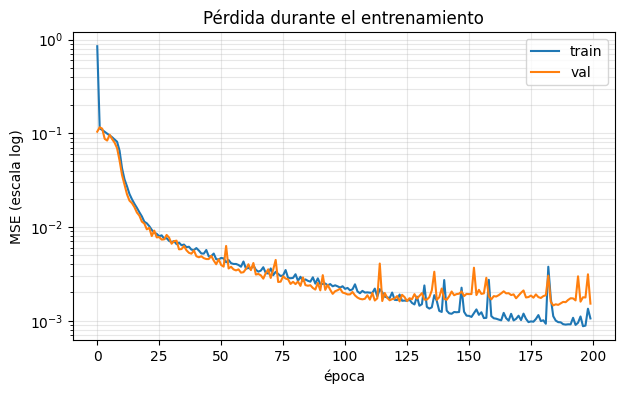

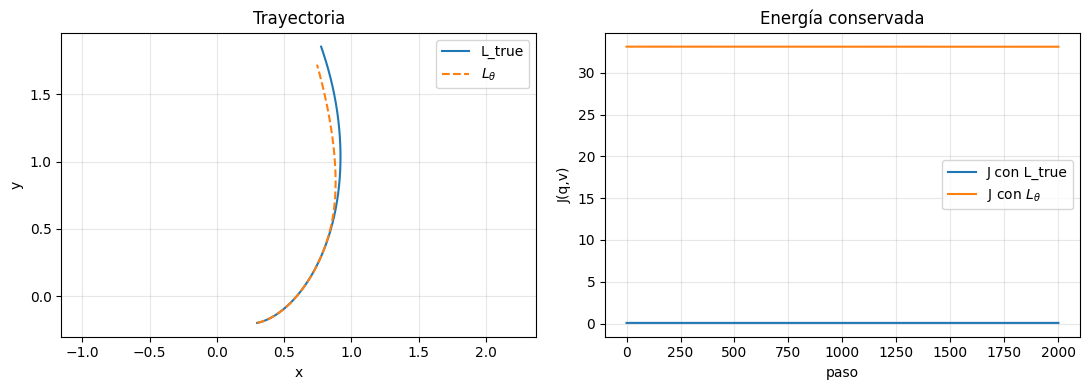

In [11]:
fig, ax = plt.subplots(figsize=(7,4))
ax.semilogy(historia["train"], label="train")
ax.semilogy(historia["val"],   label="val")
ax.set_xlabel("época"); ax.set_ylabel("MSE (escala log)")
ax.set_title("Pérdida durante el entrenamiento")
ax.grid(True, which="both", alpha=0.3); ax.legend()
plt.show()

# Integrador determinista a partir de un Lagrangiano arbitrario (Euler simpléctico-like)
def rollout(L, y0, h=1e-3, n=2000):
    cuadr = matrices(L)
    def paso_det(y, _):
        r, rd = jnp.split(y, 2)
        a = cuadr(r, rd)
        rd_n = rd + h*a
        r_n  = r  + h*rd_n
        y_n  = jnp.concatenate([r_n, rd_n])
        return y_n, y_n
    _, traj = jax.lax.scan(paso_det, y0, None, length=n)
    return jnp.vstack([y0[None], traj])

# Condición inicial de prueba (la misma para ambos)
y0_test = jnp.array([0.3, -0.2, 0.5, 0.1])

L_pred = lambda r, rd: L_theta(parametros, r, rd)
traj_true = rollout(L_true, y0_test)
traj_pred = rollout(L_pred, y0_test)

fig, axs = plt.subplots(1, 2, figsize=(11,4))
axs[0].plot(traj_true[:,0], traj_true[:,1], label="L_true")
axs[0].plot(traj_pred[:,0], traj_pred[:,1], "--", label=r"$L_\theta$")
axs[0].set_xlabel("x"); axs[0].set_ylabel("y"); axs[0].set_title("Trayectoria")
axs[0].legend(); axs[0].grid(True, alpha=0.3); axs[0].set_aspect("equal", "datalim")

# Conservación de la energía J sobre cada rollout
J_pred = J_TM(L_pred)
Js_true = jax.vmap(lambda y: J_true(*jnp.split(y,2)))(traj_true)
Js_pred = jax.vmap(lambda y: J_pred(*jnp.split(y,2)))(traj_pred)
axs[1].plot(Js_true, label="J con L_true")
axs[1].plot(Js_pred, label=r"J con $L_\theta$")
axs[1].set_xlabel("paso"); axs[1].set_ylabel("J(q,v)")
axs[1].set_title("Energía conservada"); axs[1].legend(); axs[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [12]:
import matplotlib as mpl
from pathlib import Path

mpl.rcParams.update({
    "figure.dpi"        : 110,  "savefig.dpi"       : 300,
    "savefig.bbox"      : "tight",
    "font.family"       : "serif", "font.size"      : 11,
    "axes.titlesize"    : 12, "axes.labelsize"     : 11,
    "axes.grid"         : True, "grid.alpha"       : 0.3,
    "grid.linestyle"    : "--",
    "legend.frameon"    : True, "legend.framealpha": 0.9,
    "lines.linewidth"   : 1.6,
})

C_TRUE = "#1f4e79"; C_PRED = "#c0392b"; C_ERR = "#7f8c8d"

FIG_DIR = Path("figs"); FIG_DIR.mkdir(exist_ok=True)
def guardar(fig, nombre):
    ruta = FIG_DIR / f"{nombre}.png"
    fig.savefig(ruta); print(f"  -> guardado: {ruta}")

SISTEMA = "lorentz"     # cambia a "pendulo" si entrenaste con el doble pendulo
if SISTEMA == "lorentz":
    LABELS_Q   = [r"$x$ [m]", r"$y$ [m]"]
    LABELS_QD  = [r"$\dot x$ [m/s]", r"$\dot y$ [m/s]"]
    LABELS_QDD = [r"$\ddot x$ [m/s$^2$]", r"$\ddot y$ [m/s$^2$]"]
    UNIT_E = "J"; NOMBRE = "particula cargada (Lorentz 2D)"
else:
    LABELS_Q   = [r"$\theta_1$ [rad]", r"$\theta_2$ [rad]"]
    LABELS_QD  = [r"$\dot\theta_1$ [rad/s]", r"$\dot\theta_2$ [rad/s]"]
    LABELS_QDD = [r"$\ddot\theta_1$ [rad/s$^2$]", r"$\ddot\theta_2$ [rad/s$^2$]"]
    UNIT_E = "J"; NOMBRE = "pendulo doble"

  -> guardado: figs/01_curva_aprendizaje.png


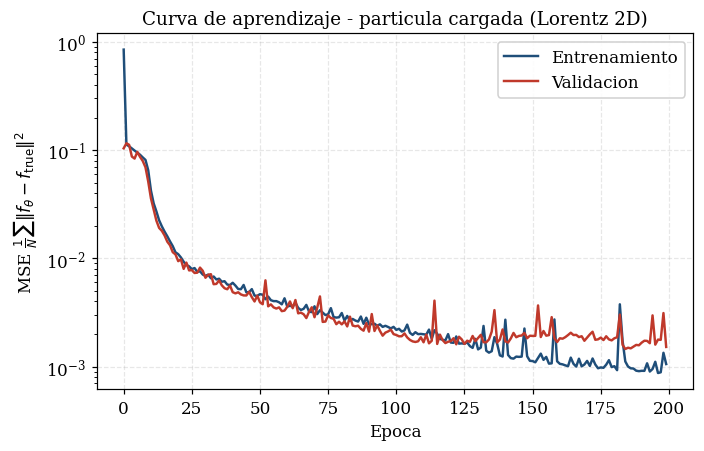

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.semilogy(historia["train"], color=C_TRUE, label="Entrenamiento")
ax.semilogy(historia["val"],   color=C_PRED, label="Validacion")
ax.set_xlabel("Epoca")
ax.set_ylabel(r"MSE $\frac{1}{N}\sum\|f_\theta - f_{\mathrm{true}}\|^2$")
ax.set_title(f"Curva de aprendizaje - {NOMBRE}")
ax.legend()
guardar(fig, "01_curva_aprendizaje"); plt.show()

  -> guardado: figs/02_series_temporales.png


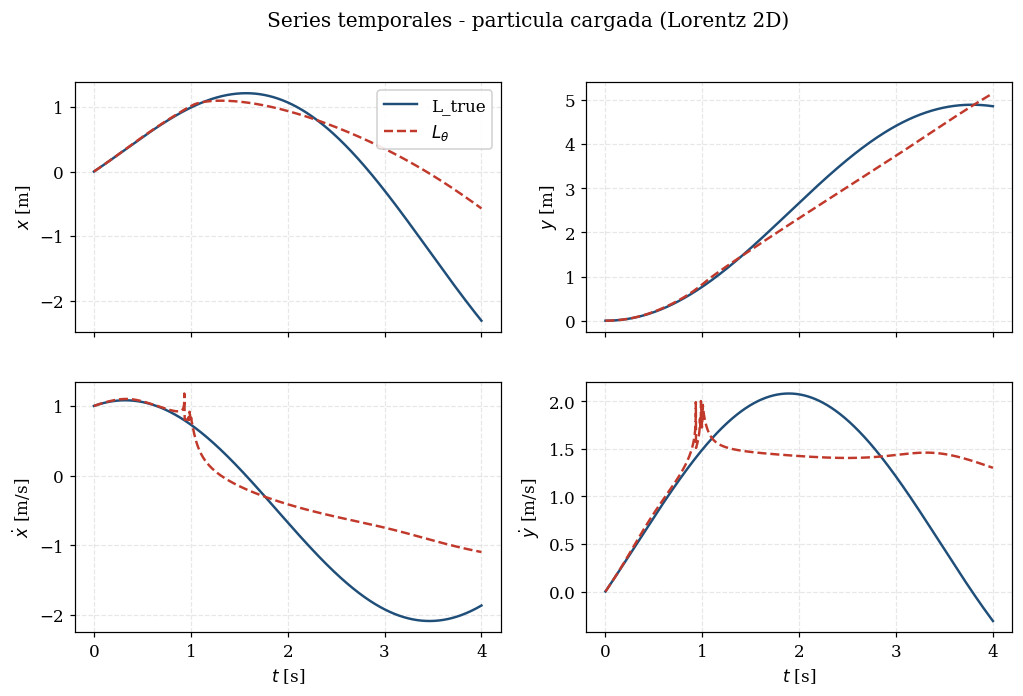

In [14]:
def rollout(L, y0, h=1e-3, n=4000):
    cuadr = matrices(L)
    def paso_det(y, _):
        r, rd = jnp.split(y, 2)
        a     = cuadr(r, rd)
        rd_n  = rd + h*a
        r_n   = r  + h*rd_n
        yn    = jnp.concatenate([r_n, rd_n])
        return yn, yn
    _, traj = jax.lax.scan(paso_det, y0, None, length=n)
    return jnp.vstack([y0[None], traj])

L_pred = lambda r, rd: L_theta(parametros, r, rd)

y0_test = jnp.array([0.0, 0.0, 1.0, 0.0]) if SISTEMA == "lorentz" \
          else jnp.array([0.6, -0.4, 0.0, 0.0])
h, n = 1e-3, 4000
t = np.arange(n + 1) * h

# BUGFIX: era 'tray_true', ahora 'traj_true'
traj_true = np.asarray(rollout(L_true, y0_test, h=h, n=n))
traj_pred = np.asarray(rollout(L_pred, y0_test, h=h, n=n))

fig, axs = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
for i in range(2):
    axs[0, i].plot(t, traj_true[:, i],   color=C_TRUE,           label="L_true")
    axs[0, i].plot(t, traj_pred[:, i],   color=C_PRED, ls="--",  label=r"$L_\theta$")
    axs[0, i].set_ylabel(LABELS_Q[i])
    axs[1, i].plot(t, traj_true[:, 2+i], color=C_TRUE,           label="L_true")
    axs[1, i].plot(t, traj_pred[:, 2+i], color=C_PRED, ls="--",  label=r"$L_\theta$")
    axs[1, i].set_ylabel(LABELS_QD[i]); axs[1, i].set_xlabel(r"$t$ [s]")
axs[0, 0].legend(loc="upper right")
fig.suptitle(f"Series temporales - {NOMBRE}")
guardar(fig, "02_series_temporales"); plt.show()

  -> guardado: figs/03_trayectoria_espacio.png


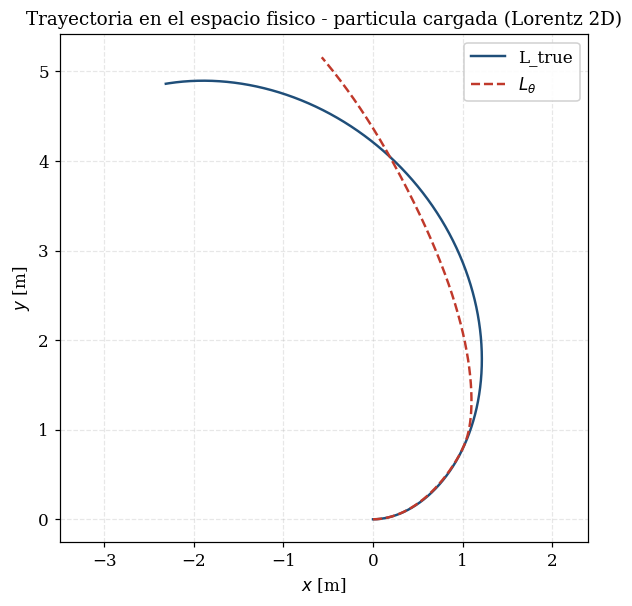

In [15]:
fig, ax = plt.subplots(figsize=(6.2, 6))
if SISTEMA == "lorentz":
    ax.plot(traj_true[:, 0], traj_true[:, 1], color=C_TRUE,          label="L_true")
    ax.plot(traj_pred[:, 0], traj_pred[:, 1], color=C_PRED, ls="--", label=r"$L_\theta$")
    ax.set_xlabel(LABELS_Q[0]); ax.set_ylabel(LABELS_Q[1])
else:
    def cart(t1, t2):
        x1 =  L1*np.sin(t1);  y1 = -L1*np.cos(t1)
        x2 =  x1 + L2*np.sin(t2); y2 = y1 - L2*np.cos(t2)
        return x1, y1, x2, y2
    _, _, xt2, yt2 = cart(traj_true[:, 0], traj_true[:, 1])
    _, _, xp2, yp2 = cart(traj_pred[:, 0], traj_pred[:, 1])
    ax.plot(xt2, yt2, color=C_TRUE,          label="L_true (bob 2)")
    ax.plot(xp2, yp2, color=C_PRED, ls="--", label=r"$L_\theta$ (bob 2)")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_aspect("equal", "datalim")
ax.set_title(f"Trayectoria en el espacio fisico - {NOMBRE}"); ax.legend()
guardar(fig, "03_trayectoria_espacio"); plt.show()

  -> guardado: figs/04_retrato_fase.png


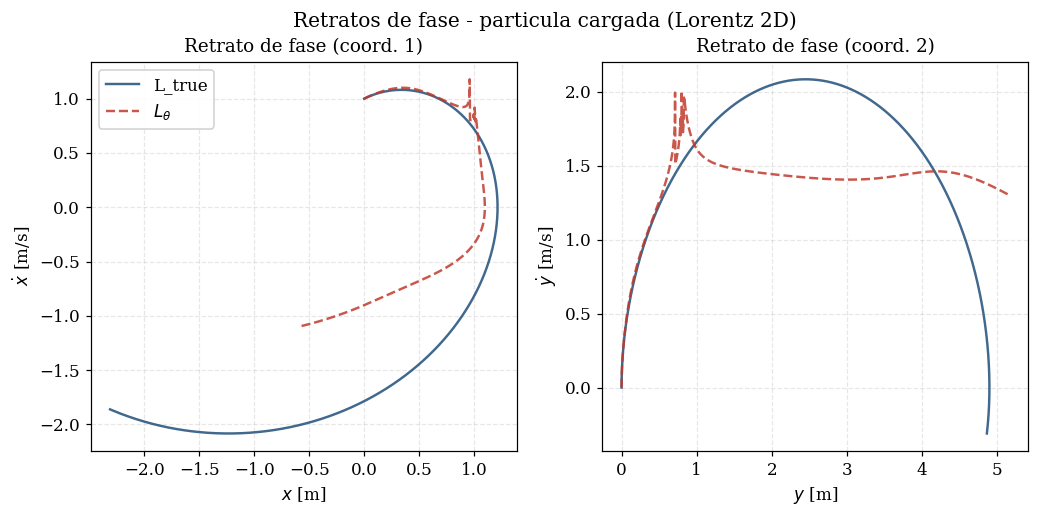

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
for i in range(2):
    axs[i].plot(traj_true[:, i], traj_true[:, 2+i],
                color=C_TRUE,          label="L_true",     alpha=0.85)
    axs[i].plot(traj_pred[:, i], traj_pred[:, 2+i],
                color=C_PRED, ls="--", label=r"$L_\theta$", alpha=0.85)
    axs[i].set_xlabel(LABELS_Q[i]); axs[i].set_ylabel(LABELS_QD[i])
    axs[i].set_title(f"Retrato de fase (coord. {i+1})")
axs[0].legend()
fig.suptitle(f"Retratos de fase - {NOMBRE}")
guardar(fig, "04_retrato_fase"); plt.show()

  -> guardado: figs/05_energia.png


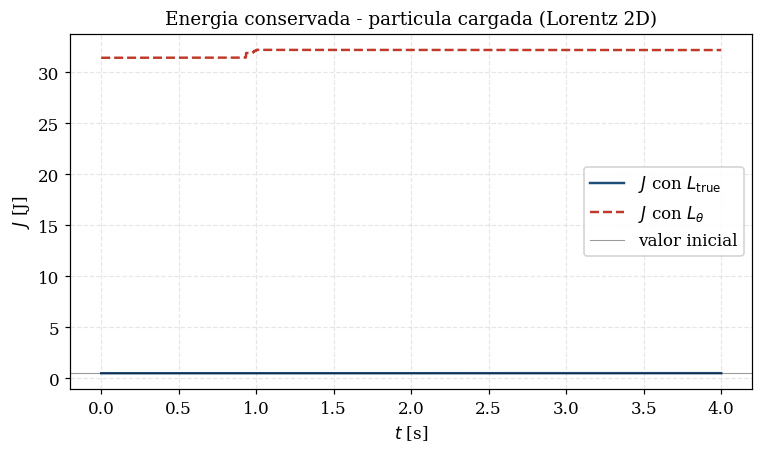

  -> guardado: figs/06_energia_deriva.png


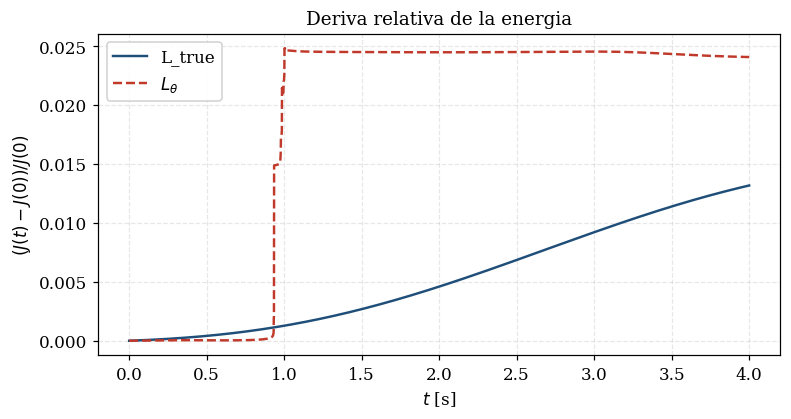

In [17]:
J_pred  = J_TM(L_pred)
Js_true = np.asarray(jax.vmap(lambda y: J_true(*jnp.split(y, 2)))(traj_true))
Js_pred = np.asarray(jax.vmap(lambda y: J_pred(*jnp.split(y, 2)))(traj_pred))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(t, Js_true, color=C_TRUE,          label=r"$J$ con $L_{\mathrm{true}}$")
ax.plot(t, Js_pred, color=C_PRED, ls="--", label=r"$J$ con $L_\theta$")
ax.axhline(Js_true[0], color="k", lw=0.7, alpha=0.4, label="valor inicial")
ax.set_xlabel(r"$t$ [s]"); ax.set_ylabel(rf"$J$ [{UNIT_E}]")
ax.set_title(f"Energia conservada - {NOMBRE}"); ax.legend()
guardar(fig, "05_energia"); plt.show()

deriv_true = (Js_true - Js_true[0]) / max(abs(Js_true[0]), 1e-12)
deriv_pred = (Js_pred - Js_pred[0]) / max(abs(Js_pred[0]), 1e-12)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(t, deriv_true, color=C_TRUE,          label="L_true")
ax.plot(t, deriv_pred, color=C_PRED, ls="--", label=r"$L_\theta$")
ax.set_xlabel(r"$t$ [s]"); ax.set_ylabel(r"$(J(t)-J(0))/J(0)$")
ax.set_title("Deriva relativa de la energia"); ax.legend()
guardar(fig, "06_energia_deriva"); plt.show()

  -> guardado: figs/07_divergencia.png


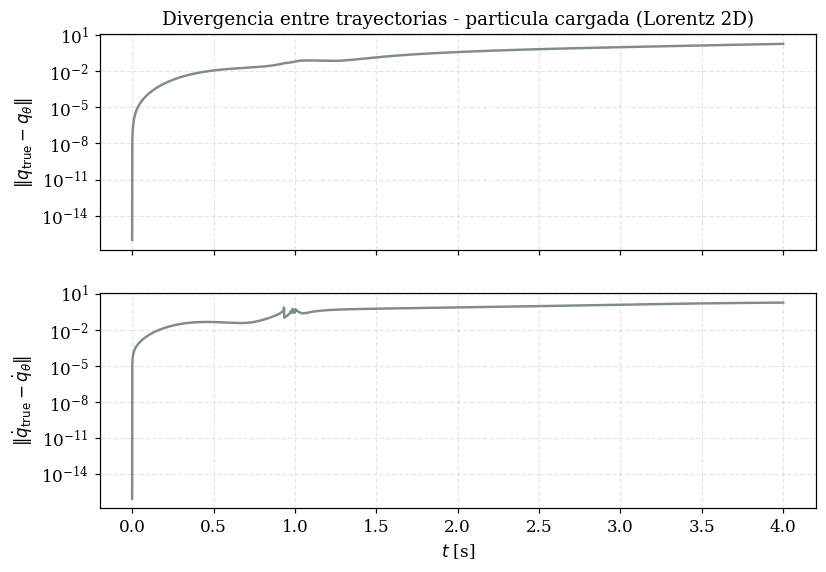

In [18]:
err_pos = np.linalg.norm(traj_true[:, :2] - traj_pred[:, :2], axis=1)
err_vel = np.linalg.norm(traj_true[:, 2:] - traj_pred[:, 2:], axis=1)

fig, axs = plt.subplots(2, 1, figsize=(8.4, 5.6), sharex=True)
axs[0].semilogy(t, err_pos + 1e-16, color=C_ERR)
axs[0].set_ylabel(r"$\|q_{\mathrm{true}} - q_\theta\|$")
axs[0].set_title(f"Divergencia entre trayectorias - {NOMBRE}")
axs[1].semilogy(t, err_vel + 1e-16, color=C_ERR)
axs[1].set_ylabel(r"$\|\dot q_{\mathrm{true}} - \dot q_\theta\|$")
axs[1].set_xlabel(r"$t$ [s]")
guardar(fig, "07_divergencia"); plt.show()

  -> guardado: figs/08_paridad.png


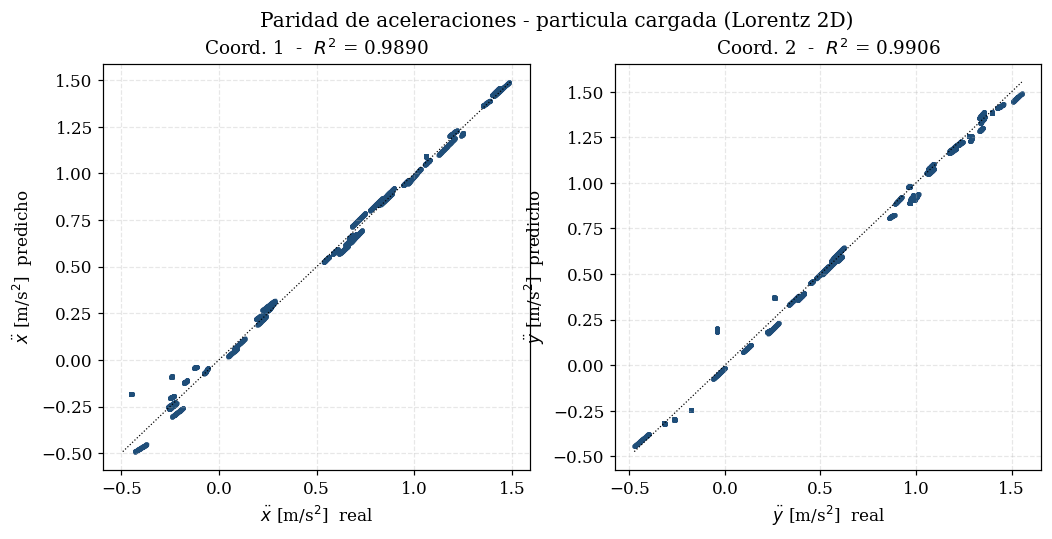

In [19]:
a_true = np.asarray(Y_val[:, DIM:])
eom_theta = jax.jit(jax.vmap(eom_desde_L(lambda r, rd: L_theta(parametros, r, rd))))
a_pred = np.asarray(eom_theta(X_val)[:, DIM:])

fig, axs = plt.subplots(1, 2, figsize=(11, 4.8))
for i in range(2):
    ax = axs[i]
    ax.scatter(a_true[:, i], a_pred[:, i], s=4, alpha=0.35, color=C_TRUE)
    lim = [min(a_true[:, i].min(), a_pred[:, i].min()),
           max(a_true[:, i].max(), a_pred[:, i].max())]
    ax.plot(lim, lim, color="k", lw=0.8, ls=":")
    ax.set_xlabel(f"{LABELS_QDD[i]}  real")
    ax.set_ylabel(f"{LABELS_QDD[i]}  predicho")
    ss_res = np.sum((a_pred[:, i] - a_true[:, i])**2)
    ss_tot = np.sum((a_true[:, i] - a_true[:, i].mean())**2) + 1e-30
    r2 = 1 - ss_res/ss_tot
    ax.set_title(f"Coord. {i+1}  -  $R^2$ = {r2:.4f}")
fig.suptitle(f"Paridad de aceleraciones - {NOMBRE}")
guardar(fig, "08_paridad"); plt.show()

  -> guardado: figs/09_residuos.png


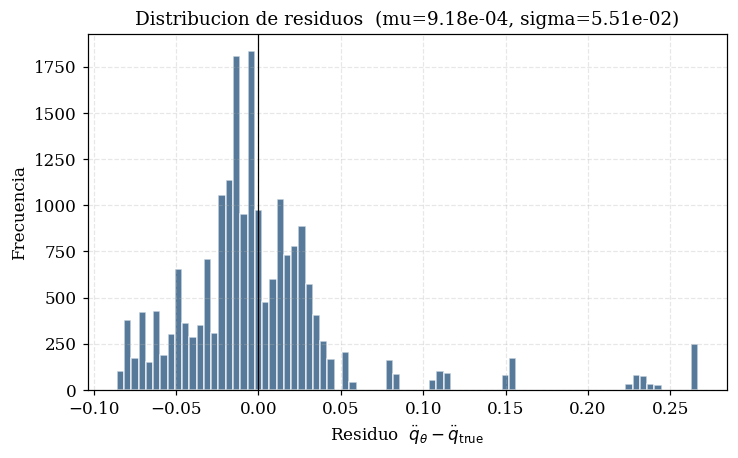

In [20]:
res = (a_pred - a_true).ravel()
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.hist(res, bins=80, color=C_TRUE, alpha=0.75, edgecolor="white")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel(r"Residuo  $\ddot q_\theta - \ddot q_{\mathrm{true}}$")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Distribucion de residuos  (mu={res.mean():.2e}, sigma={res.std():.2e})")
guardar(fig, "09_residuos"); plt.show()

  -> guardado: figs/10_campo_vectorial.png


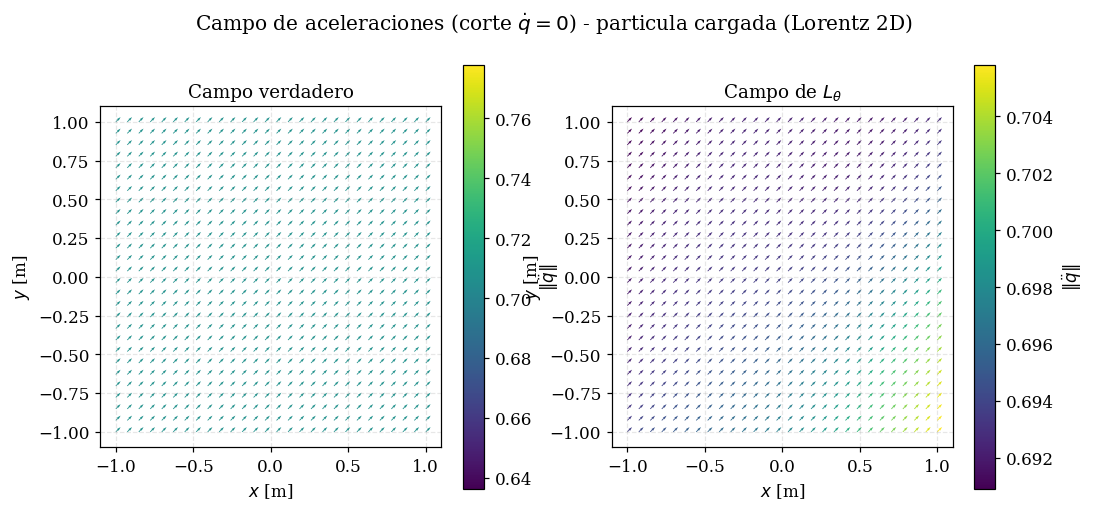

In [21]:
N = 28
q1 = np.linspace(-1.0, 1.0, N); q2 = np.linspace(-1.0, 1.0, N)
Q1, Q2 = np.meshgrid(q1, q2)
Y0 = np.stack([Q1.ravel(), Q2.ravel(),
               np.zeros(N*N), np.zeros(N*N)], axis=1)

a_true_grid = np.asarray(jax.vmap(eom_desde_L(L_true))(jnp.asarray(Y0)))[:, DIM:]
a_pred_grid = np.asarray(eom_theta(jnp.asarray(Y0)))[:, DIM:]

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
for ax, A, titulo in [(axs[0], a_true_grid, "Campo verdadero"),
                      (axs[1], a_pred_grid, r"Campo de $L_\theta$")]:
    U = A[:, 0].reshape(N, N); V = A[:, 1].reshape(N, N)
    M = np.hypot(U, V)
    q = ax.quiver(Q1, Q2, U, V, M, cmap="viridis", scale=None)
    ax.set_xlabel(LABELS_Q[0]); ax.set_ylabel(LABELS_Q[1])
    ax.set_title(titulo); ax.set_aspect("equal")
    plt.colorbar(q, ax=ax, label=r"$\|\ddot q\|$")
fig.suptitle(f"Campo de aceleraciones (corte $\\dot q=0$) - {NOMBRE}")
guardar(fig, "10_campo_vectorial"); plt.show()

  -> guardado: figs/11_lyapunov.png


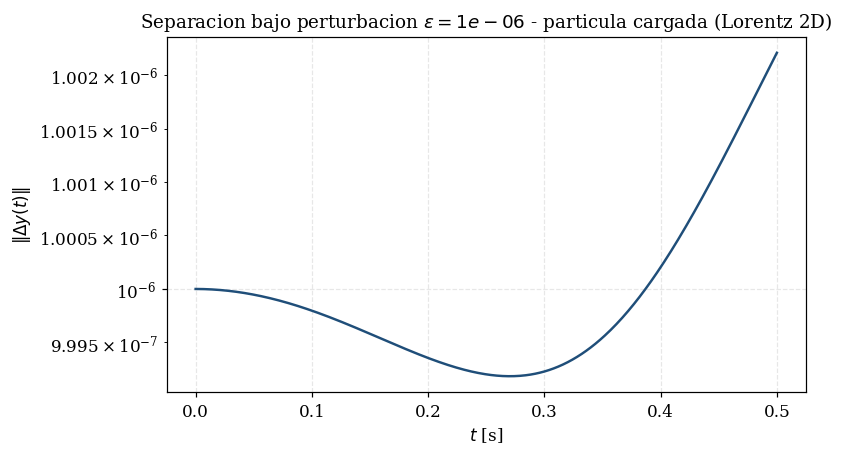

In [22]:
eps, n_pertub = 1e-6, 500
y0_pert = y0_test.at[0].add(eps)

traj_a = np.asarray(rollout(L_pred, y0_test, h=h, n=n_pertub))
traj_b = np.asarray(rollout(L_pred, y0_pert, h=h, n=n_pertub))
sep    = np.linalg.norm(traj_a - traj_b, axis=1)
tp     = np.arange(n_pertub + 1) * h

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogy(tp, sep + 1e-20, color=C_TRUE)
ax.set_xlabel(r"$t$ [s]"); ax.set_ylabel(r"$\|\Delta y(t)\|$")
ax.set_title(rf"Separacion bajo perturbacion $\epsilon={eps:.0e}$ - {NOMBRE}")
guardar(fig, "11_lyapunov"); plt.show()

In [23]:
mse_val   = float(perdida(parametros, X_val, Y_val))
mae_val   = float(jnp.mean(jnp.abs(eom_theta(X_val) - Y_val)))
J_drift   = float(np.max(np.abs(deriv_pred)))
max_err_q = float(err_pos.max())

print("=" * 58)
print(f" Resumen - {NOMBRE}")
print("=" * 58)
print(f" MSE validacion              : {mse_val:.4e}")
print(f" MAE validacion              : {mae_val:.4e}")
print(f" Deriva max. de J (relativa) : {J_drift:.4e}")
print(f" Error max. de posicion      : {max_err_q:.4e}  [unid. de q]")
print(f" Horizonte simulado          : {t[-1]:.2f} s   ({n} pasos, h={h})")
print("=" * 58)

 Resumen - particula cargada (Lorentz 2D)
 MSE validacion              : 1.5180e-03
 MAE validacion              : 1.6954e-02
 Deriva max. de J (relativa) : 2.4858e-02
 Error max. de posicion      : 1.7656e+00  [unid. de q]
 Horizonte simulado          : 4.00 s   (4000 pasos, h=0.001)


# Referencias

[1] Cranmer M, Greydanus S, Hoyer S, Battaglia P, Spergel D, Ho S. Lagrangian neural networks. arXiv preprint arXiv:2003.04630. 2020 Mar 10.

[2] Mann P. Lagrangian and Hamiltonian dynamics. Oxford: Oxford University Press; 2018.

[3] Bajars J. Locally-symplectic neural networks for learning volume-preserving dynamics. J Comput Phys. 2021;10.1016/j.jcp.2023.111911.

[4] Tapley B. Symplectic Neural Networks Based on Dynamical Systems. ArXiv preprint arXiv:2408.09821. 2024.

[5] Jin P, Zhang Z, Zhu A, Tang Y, Karniadakis G. SympNets: Intrinsic structure-preserving symplectic networks for identifying Hamiltonian systems. Neural Networks. 2020;10.1016/j.neunet.2020.08.017.

[6] Duruisseaux V, Burby J, Tang Q. Approximation of nearly-periodic symplectic maps via structure-preserving neural networks. Sci Rep. 2022;10.1038/s41598-023-34862-w.

[7] Canizares P, Murari D, Schönlieb C, Sherry F, Shumaylov Z. Symplectic Neural Flows for Modeling and Discovery. ArXiv preprint arXiv:2412.16787. 2024.

[8] Tong Y, Xiong S, He X, Pan G, Zhu B. Symplectic Neural Networks in Taylor Series Form for Hamiltonian Systems. ArXiv preprint arXiv:2020.110325. 2020.

[9] Liang C, Wen X, Zhu Z, Shen L, Wang Y. SPINI: a structure-preserving neural integrator for hamiltonian dynamics and parametric perturbation. Sci Rep. 2025;10.1038/s41598-025-28710-2.

[10] Chen Z, Zhang J, Arjovsky M, Bottou L. Symplectic Recurrent Neural Networks. ArXiv preprint. 2019.

[11] Papatheodorou A, Vaidhyanathan P, Ares N, Havoutis I. Learning Physical Systems: Symplectification via Gauge Fixing in Dirac Structures. ArXiv preprint arXiv:2506.18812. 2025.

[12] Horn P, Ulibarrena VS, Koren B, Zwart SP. A generalized framework of neural networks for Hamiltonian systems. J Comput Phys. 2024;10.1016/j.jcp.2024.113536.

[13] Desai N, Matthew M, Roberts S. Hamiltonian Neural Networks with Automatic Symmetry Detection. ArXiv preprint arXiv:2110.04561. 2021.

[14] Khadir A, Benner P. Reduced-order modeling of Hamiltonian dynamics based on symplectic neural networks. J Comput Phys. 2023;10.1016/j.jcp.2023.112104.

[15] Matsubara T, Ishikawa Y, Yaguchi T. Learning Hamiltonian Systems with Pseudo-symplectic Neural Networks. IEEE Trans Neural Netw Learn Syst. 2020;10.1109/TNNLS.2020.3015981.

[16] Zhu A, Jin P, Tang Y. Symplectic networks: Intrinsic structure-preserving networks for identifying Hamiltonian systems. Comput Methods Appl Mech Eng. 2022;10.1016/j.cma.2022.115024.

[17] Xiong S, Tong Y, Pan G, Zhu B. Symplectic physics-embedded learning via Lie group action. ArXiv preprint arXiv:2305.01245. 2023.

[18] Wang Y, Zhang Z, Shi J. Deep Neural Networks with Symplectic Preservation for Hamiltonian Systems. J Sci Comput. 2024;10.1007/s10915-024-02511-w.

[19] Miller M, Shvartsman I. Symplectic encoders for physics-constrained variational autoencoders. ArXiv preprint arXiv:2209.08341. 2022.

[20] Buchfink P, Haasdonk B. Symplectic Autoencoders for Model Reduction of Hamiltonian Systems. SIAM J Sci Comput. 2023;10.1137/22M1491024.

[21] Greydanus S, Dzamba M, Yosinski J. Structure-Preserving Neural Networks for the N-body Problem. NeurIPS Workshop. 2019.

[22] Aboussalah AM, Ed-Dib M. GeoHNNs: Geometric Hamiltonian Neural Networks. ArXiv preprint arXiv:2507.15678. 2025.